Investiages potential causes for the high correlation between Gold Price & 10Y Real Yied, using the combined_dataset.csv. 
The dataset contains news events from WRDS Ravenpack event dataset + ACM 10Y Term Premium, which is drawn as a confounder
in previous causal DAG's created for Gold Return that include 10Y Real Yield.

In those DAGs, 10Y Real Yield <- ACM 10Y Term Premium -> Gold Returns

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

PATH = Path.cwd()
DATA_DIR = PATH / 'data'

CORR_PATH = DATA_DIR / 'gold_price_real_yield_acm.csv'

df = pd.read_csv(CORR_PATH, index_col=0, parse_dates=True)

In [2]:
# levels correlation fractions
count_corr_lvl = (df['Rolling Correlation levels'].abs() > 0.60).sum()
count_total = df.shape[0]
fraction = (count_corr_lvl / count_total) * 100
print("Levels Rolling Correlaton Fractions")
print(f"fraction of values where |rolling correlation| > 0.60: {fraction}")

count_pos_lvl = (df['Rolling Correlation levels'] > 0.60).sum()
fraction_pos = (count_pos_lvl / count_total) * 100
print(f"fraction of values where rolling correlation > 0.60: {fraction_pos}")

count_neg_lvl = (df['Rolling Correlation levels'] < -0.60).sum()
fraction_neg = (count_neg_lvl / count_total) * 100
print(f"fraction of values where rolling correlation < -0.60: {fraction_neg}")

print(fraction_neg + fraction_pos, fraction)

#changes correlation fractions
count_corr_logs = (df['Rolling Correlation logs'].abs() > 0.60).sum()
fraction_logs = (count_corr_logs / count_total) * 100
print("Logs Rolling Correlation Fractions")
print(f"fraction of values where |rolling correlation log difference| > 0.60: {fraction_logs}")

count_pos_logs = (df['Rolling Correlation logs'] > 0.60).sum()
fraction_pos_logs = (count_pos_logs / count_total) * 100
print(f"fraction of values where rolling correlation logs difference > 0.60: {fraction_pos_logs}")

count_neg_logs = (df['Rolling Correlation logs'] < -0.60).sum()
fraction_neg_logs = (count_neg_logs / count_total) * 100
print(f"fraction of values where rolling correlation logs difference < -0.60: {fraction_neg_logs}")

print(fraction_pos_logs + fraction_neg_logs, fraction_logs)

Levels Rolling Correlaton Fractions
fraction of values where |rolling correlation| > 0.60: 41.93061840120664
fraction of values where rolling correlation > 0.60: 3.6010558069381595
fraction of values where rolling correlation < -0.60: 38.32956259426848
41.930618401206644 41.93061840120664
Logs Rolling Correlation Fractions
fraction of values where |rolling correlation log difference| > 0.60: 6.8815987933635
fraction of values where rolling correlation logs difference > 0.60: 0.0
fraction of values where rolling correlation logs difference < -0.60: 6.8815987933635
6.8815987933635 6.8815987933635


In [3]:
# Postive levels analysis 
df_pos_days = df[df['Rolling Correlation levels'] > 0.60].copy()
df_pos_days['date'] = df_pos_days.index.to_series()
df_pos_days['Timedelta'] = df_pos_days['date'].diff()
df_pos_days['New episode'] = df_pos_days['Timedelta'] > pd.Timedelta(days=60)
df_pos_days['New episode ID'] = df_pos_days['New episode'].cumsum()
count_pos_days = df_pos_days['date'].agg('count')
df_episode_info = df_pos_days.groupby('New episode ID')['date'].agg(['count', 'min', 'max'])
print(count_pos_days, df_episode_info)

# dict of all episode IDs with corresponding 60d before start of episode
pre_windows = {}
for ep_id in df_episode_info.index:
    min_ep_id = df_episode_info.loc[ep_id, 'min']
    sixty_before = min_ep_id - pd.Timedelta(days=60)
    sliced_df = df.loc[sixty_before: min_ep_id]
    pre_windows[ep_id] = sliced_df

for id, dataframe in pre_windows.items():
    print(id, len(dataframe))


191                 count        min        max
New episode ID                             
0                   8 2005-03-11 2005-03-22
1                  22 2005-10-12 2005-12-22
2                  21 2006-04-07 2006-05-09
3                  19 2007-04-12 2007-05-08
4                   4 2007-08-27 2007-08-30
5                  12 2008-09-25 2008-10-10
6                   1 2010-03-18 2010-03-18
7                  11 2011-12-23 2012-01-12
8                   8 2012-05-18 2012-05-31
9                  18 2013-08-22 2013-10-16
10                 24 2018-07-03 2018-11-08
11                 20 2024-04-11 2024-05-08
12                 13 2024-10-23 2024-11-08
13                 10 2025-12-22 2026-01-08
0 41
1 39
2 43
3 41
4 41
5 42
6 40
7 41
8 44
9 42
10 41
11 40
12 39
13 39


In [4]:
# episode contamination, how far does one episode 60d lookback reach into another episodes timeframe (min to max)
df_episode_info['ep duration'] = df_episode_info['max'] - df_episode_info['min']
df_episode_info['lookback_lag'] = (df_episode_info['min'] - pd.Timedelta(days=60))
df_episode_info['contaminated'] = df_episode_info['lookback_lag'] < df_episode_info['max'].shift(1)
df_episode_info

,count,min,max,ep duration,lookback_lag,contaminated
New episode ID,,,,,,
0,8,2005-03-11,2005-03-22,11 days,2005-01-10,False
1,22,2005-10-12,2005-12-22,71 days,2005-08-13,False
2,21,2006-04-07,2006-05-09,32 days,2006-02-06,False
3,19,2007-04-12,2007-05-08,26 days,2007-02-11,False
4,4,2007-08-27,2007-08-30,3 days,2007-06-28,False
5,12,2008-09-25,2008-10-10,15 days,2008-07-27,False
6,1,2010-03-18,2010-03-18,0 days,2010-01-17,False
7,11,2011-12-23,2012-01-12,20 days,2011-10-24,False
8,8,2012-05-18,2012-05-31,13 days,2012-03-19,False


In [5]:
# keeps episodes with strictly more than 5 rows of valid data, shown in count column of df_episode_info. Minimum one trading week above threshold
df_episode_info = df_episode_info[df_episode_info['count'] > 5]
df_episode_info

,count,min,max,ep duration,lookback_lag,contaminated
New episode ID,,,,,,
0,8,2005-03-11,2005-03-22,11 days,2005-01-10,False
1,22,2005-10-12,2005-12-22,71 days,2005-08-13,False
2,21,2006-04-07,2006-05-09,32 days,2006-02-06,False
3,19,2007-04-12,2007-05-08,26 days,2007-02-11,False
5,12,2008-09-25,2008-10-10,15 days,2008-07-27,False
7,11,2011-12-23,2012-01-12,20 days,2011-10-24,False
8,8,2012-05-18,2012-05-31,13 days,2012-03-19,False
9,18,2013-08-22,2013-10-16,55 days,2013-06-23,False
10,24,2018-07-03,2018-11-08,128 days,2018-05-04,False


In [6]:
# did gold price and real 10Y yield actually rise during each episode? 
# real yield = nominal yield − breakeven inflation, therefore Δreal = Δnominal − Δbreakeven.
# Units: gold_pct = decimal fraction (0.0232 = 2.32%), ratio = pure share (0.68 = 68%), rate columns = percentage-point changes (0.37 = 37bp)

rows = []
for ep_id in df_episode_info.index:
    start = df_episode_info.loc[ep_id, 'min'] - pd.Timedelta(days=30)
    end = df_episode_info.loc[ep_id, 'max']
    gold_start = df['Gold Price'].asof(start)
    gold_end = df.loc[end, 'Gold Price']
    yield_start = df['10Y Real Yield'].asof(start)
    yield_end = df.loc[end, '10Y Real Yield']
    acm_start = df['acm_tp_level'].asof(start)
    acm_end = df.loc[end, 'acm_tp_level']
    gold_pct = (gold_end - gold_start) / gold_start
    yield_chg = yield_end - yield_start
    acm_chg = acm_end - acm_start
    breakeven_start = df['10Y Breakeven'].asof(start)
    breakeven_end = df.loc[end, '10Y Breakeven']
    breakeven_chg = breakeven_end - breakeven_start

    nominal_chg = yield_chg + breakeven_chg
    tp_share_nom = acm_chg / nominal_chg
    exp_rate_chg = nominal_chg - acm_chg

    rows.append({'ep_id': ep_id, 'start':start, 'end': end, 
                 'gold_pct': gold_pct, 'yield_chg': yield_chg, 
                 'acm_chg': acm_chg, 'breakeven_chg': breakeven_chg,
                 'nominal_chg': nominal_chg, 'tp_share_nom': tp_share_nom,
                 'exp_rate_chg': exp_rate_chg})

summary = pd.DataFrame(rows)
print(summary)

    ep_id      start        end  gold_pct  yield_chg  acm_chg  breakeven_chg  \
0       0 2005-02-09 2005-03-22  0.044563       0.38   0.2716           0.25   
1       1 2005-09-12 2005-12-22  0.117856       0.42   0.0639          -0.16   
2       2 2006-03-08 2006-05-09  0.289217       0.23   0.1219           0.17   
3       3 2007-03-13 2007-05-08  0.057906       0.12   0.0840           0.01   
4       5 2008-08-26 2008-10-10  0.040379       1.34   0.2988          -1.24   
5       7 2011-11-23 2012-01-12 -0.028543      -0.09  -0.0028           0.14   
6       8 2012-04-18 2012-05-31 -0.046497      -0.24  -0.1912          -0.17   
7       9 2013-07-23 2013-10-16 -0.039772       0.17   0.0763          -0.01   
8      10 2018-06-03 2018-11-08 -0.055530       0.37   0.0937          -0.02   
9      11 2024-03-12 2024-05-08  0.070913       0.31   0.1802           0.01   
10     12 2024-09-23 2024-11-08  0.023225       0.37   0.3734           0.18   
11     13 2025-11-22 2026-01-08  0.09149

In [7]:
# classifying the direction
conditions_gld = [summary['gold_pct'] > 0.02,
                summary['gold_pct'] < -0.02]
labels_gld = ['up', 'down']
summary['direction_gold'] = np.select(conditions_gld, labels_gld, default='flat')
conditions_yield = [summary['yield_chg'] > 0.05,
                    summary['yield_chg'] < -0.05]
labels_yield = ['up', 'down']
summary['direction_yield'] = np.select(conditions_yield, labels_yield, default='flat')
summary['direction'] = summary['direction_gold'] + '/' + summary['direction_yield']
summary = summary.drop(columns=['direction_gold', 'direction_yield'])

summary['ratio'] = (summary['acm_chg'] / summary['yield_chg']).where(summary['yield_chg'] > 0)
summary['tp_share_nom'] = (summary['acm_chg'] / summary['nominal_chg']).where(summary['nominal_chg'].abs() > 0.15)
summary = summary.set_index('ep_id')
summary

,start,end,gold_pct,yield_chg,acm_chg,breakeven_chg,nominal_chg,tp_share_nom,exp_rate_chg,direction,ratio
ep_id,,,,,,,,,,,
0,2005-02-09,2005-03-22,0.044563,0.38,0.2716,0.25,0.63,0.431111,0.3584,up/up,0.714737
1,2005-09-12,2005-12-22,0.117856,0.42,0.0639,-0.16,0.26,0.245769,0.1961,up/up,0.152143
2,2006-03-08,2006-05-09,0.289217,0.23,0.1219,0.17,0.40,0.304750,0.2781,up/up,0.530000
3,2007-03-13,2007-05-08,0.057906,0.12,0.0840,0.01,0.13,NaN,0.0460,up/up,0.700000
5,2008-08-26,2008-10-10,0.040379,1.34,0.2988,-1.24,0.10,NaN,-0.1988,up/up,0.222985
7,2011-11-23,2012-01-12,-0.028543,-0.09,-0.0028,0.14,0.05,NaN,0.0528,down/down,NaN
8,2012-04-18,2012-05-31,-0.046497,-0.24,-0.1912,-0.17,-0.41,0.466341,-0.2188,down/down,NaN
9,2013-07-23,2013-10-16,-0.039772,0.17,0.0763,-0.01,0.16,0.476875,0.0837,down/up,0.448824
10,2018-06-03,2018-11-08,-0.055530,0.37,0.0937,-0.02,0.35,0.267714,0.2563,down/up,0.253243


In [8]:
# baseline test
# are the term premium moves in these episodes unusually large compared to ordinary times

episode_mask = pd.Series(False, index=df.index)
for i in summary.index:
    start = summary.loc[i, 'start']
    end = summary.loc[i, 'end']
    episode_mask.loc[start:end] = True

print(episode_mask.sum())

rows = []
for i in summary.index: 
    start = summary.loc[i, 'start']
    end = summary.loc[i, 'end']
    acm_chg = summary.loc[i, 'acm_chg']
    start_pos = df.index.get_indexer([start], method='pad')[0]
    end_pos = df.index.get_loc(end)
    n = end_pos - start_pos
    changes = df['acm_tp_level'].diff(n).dropna()
    contaminated = episode_mask.rolling(n+1).max().astype(bool)
    null_dist = changes[(~contaminated) & changes.notna()]
    pct = round((null_dist < acm_chg).mean(),2)

    rows.append({
        'ep_id': i, 'n_trading_days': n, 
        'acm_chg': acm_chg, 'percentile': pct,
        'null_count': len(null_dist)
    })

baseline = pd.DataFrame(rows).set_index('ep_id')
baseline.to_csv(PATH / 'PowerBI data' / 'acm_baseline.csv')



539


2005-07 (eps 0-3, up/up): door A GENUINELY open (exp rates +0.05..+0.36) yet gold rallied +4..+29%. Demand boom (commodity supercycle, GLD launch Nov-04, EM buying) overpowered a real cost increase. Yield channel existed but weak pre-GFC.

2008 (ep 5, up/up): breakevens -1.24 (deflation panic), exp rates -0.20 (flight to safety), nominal +0.10 only. Measured real-yield spike = breakeven collapse + TIPS illiquidity premium inside DFII10 (market seized, dealers dumped TIPS). Gold rose on panic. Largely a distorted measure, not gold defying real rates.

2011-12 (eps 7-8, down/down): everything falling (exp rates, TP, breakevens) = deleveraging / eurozone risk-off. Gold fell WITH yields; positive corr from shared downtrend.

2013 & 2018 (eps 9-10, down/up): door A honestly (taper, Fed hikes; ep 10 exp +0.26, low TP share 0.27). Gold FELL. The normal channel working = control group. Their high level-corr is path co-movement, not net co-trend

2024-26 (eps 11-13, up/up): door B era. TP shares 0.56-0.89, exp rates ~flat-to-mild (+0.01..+0.18); late-2024 breakevens +0.18 too = fiscal/inflation-risk repricing, both
components gold-bullish. Gold rallied through rising yields. Headline finding. ep 12 exp rates ROSE +0.18; story is TP + breakevens rising together.


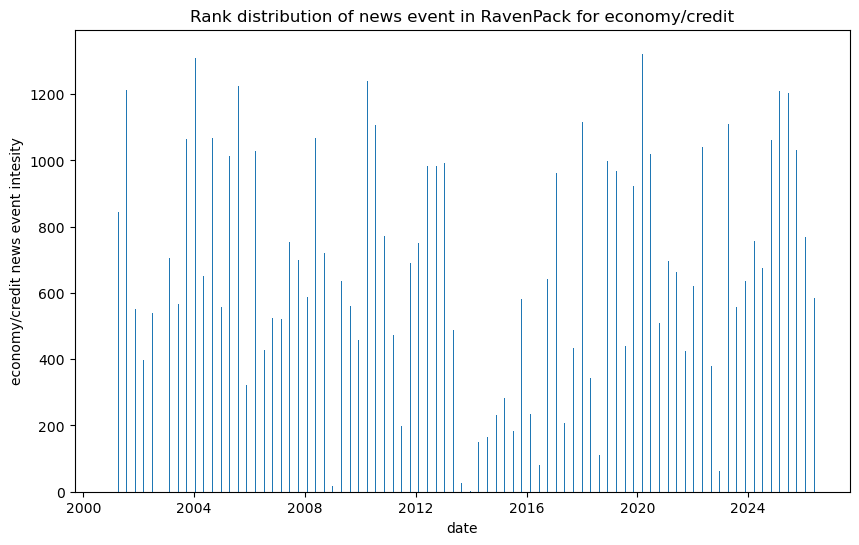

In [ ]:
# # News-event (RavenPack) investigation
# import matplotlib.pyplot as plt 

# PATH = PATH.cwd()
# RAVENPACK_DATASET = PATH / 'ravenpack data'
# INTENSITY_CSV_PATH = RAVENPACK_DATASET / 'intensity_weekly.csv'

# intensity = pd.read_csv(INTENSITY_CSV_PATH, index_col=0, parse_dates=True)
# roll = intensity.rolling(104, min_periods=52)
# z = (intensity - roll.mean()) / roll.std()

# fig, ax = plt.subplots(figsize=(10,6))
# ax.bar(z.index, z['economy/credit'].rank())
# ax.set_xlabel('date')
# ax.set_ylabel('economy/credit news event intesity')
# ax.set_title('Rank distribution of news event in RavenPack for economy/credit')
# plt.savefig('distribution_news_events_economy-credit.png')
# plt.show()


In [10]:
# adding change of tonnes of gold from GLD archive into summary dataframe -> new_summary dataframe
PATH = Path.cwd()
US_GLD_ARCHIVE_PATH = PATH / 'data' / 'US_GLD_Archive_EN.xlsx'

df_gld = pd.read_excel(US_GLD_ARCHIVE_PATH, sheet_name='US GLD Historical Archive', index_col=0, parse_dates=True)
df_gld = df_gld.apply(pd.to_numeric, errors='coerce')
df_gld.info()
df_gld.dropna(inplace=True)

rows = []
for ep_id in summary.index:
    start = summary.loc[ep_id, 'start']
    end = summary.loc[ep_id, 'end']
    start_tonnes = df_gld['Tonnes of Gold'].asof(start)
    end_tonnes = df_gld['Tonnes of Gold'].loc[end]

    change_in_tonnes = end_tonnes - start_tonnes

    rows.append({
        'ep_id': ep_id,
        'change_in_tonnes': change_in_tonnes})

change_tonnes_df = pd.DataFrame(rows).set_index('ep_id')
new_summary = summary.merge(change_tonnes_df, on='ep_id')
new_summary

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5655 entries, 2004-11-18 to 2026-07-23
Data columns (total 10 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   Closing Price                                                               5451 non-null   float64
 1   Ounces of Gold per Share                                                    5451 non-null   float64
 2   NAV/Share at 10:30am NYT                                                    5451 non-null   float64
 3   Indicative Price per Share at 4:15pm NYT                                    5451 non-null   float64
 4   Mid point of bid/ask spread at 4:15pm NYT                                   5451 non-null   float64
 5   Premium/Discount of GLD Mid Point vs Indicative Value of GLD at 4:15pm NYT  5448 non-null   float64
 6   Daily Share Volume            

,start,end,gold_pct,yield_chg,acm_chg,breakeven_chg,nominal_chg,tp_share_nom,exp_rate_chg,direction,ratio,change_in_tonnes
ep_id,,,,,,,,,,,,
0,2005-02-09,2005-03-22,0.044563,0.38,0.2716,0.25,0.63,0.431111,0.3584,up/up,0.714737,8.96
1,2005-09-12,2005-12-22,0.117856,0.42,0.0639,-0.16,0.26,0.245769,0.1961,up/up,0.152143,40.37
2,2006-03-08,2006-05-09,0.289217,0.23,0.1219,0.17,0.40,0.304750,0.2781,up/up,0.530000,2.89
3,2007-03-13,2007-05-08,0.057906,0.12,0.0840,0.01,0.13,NaN,0.0460,up/up,0.700000,2.77
5,2008-08-26,2008-10-10,0.040379,1.34,0.2988,-1.24,0.10,NaN,-0.1988,up/up,0.222985,119.27
7,2011-11-23,2012-01-12,-0.028543,-0.09,-0.0028,0.14,0.05,NaN,0.0528,down/down,NaN,-43.16
8,2012-04-18,2012-05-31,-0.046497,-0.24,-0.1912,-0.17,-0.41,0.466341,-0.2188,down/down,NaN,-15.91
9,2013-07-23,2013-10-16,-0.039772,0.17,0.0763,-0.01,0.16,0.476875,0.0837,down/up,0.448824,-44.23
10,2018-06-03,2018-11-08,-0.055530,0.37,0.0937,-0.02,0.35,0.267714,0.2563,down/up,0.253243,-81.19


In [11]:
# map regime labels to episode id
mapping = {0: 'Demand Boom', 1: 'Demand Boom', 2: 'Demand Boom', 3: 'Demand Boom', 
           5: 'Broken Gauge', 7: 'Eurozone Risk-Off', 8: 'Eurozone Risk-Off',
           9: 'Control', 10: 'Control', 11: 'Fiscal Premia', 12: 'Fiscal Premia', 13: 'Fiscal Premia'}
new_summary['Regime'] = new_summary.index.map(mapping)
new_summary.to_csv(PATH / 'PowerBI data' / 'episode_regime_breakdown.csv')

In [12]:
# Tests the ETF-demand hypothesis: pool restricted to 2005-07 to hold the adoption ramp constant
df_gld_boom = df_gld[['Tonnes of Gold']].loc['2005':'2007']
gold_boom_ep_id = [0, 1, 2, 3]
episode_mask_gld = pd.Series(False, index=df_gld_boom.index)
for i in gold_boom_ep_id:
    start = new_summary.loc[i, 'start']
    end = new_summary.loc[i, 'end']
    episode_mask_gld.loc[start:end] = True

print(episode_mask_gld.sum())

rows = []
for i in gold_boom_ep_id: 
    start = new_summary.loc[i, 'start']
    end = new_summary.loc[i, 'end']
    tonnes_chg = new_summary.loc[i, 'change_in_tonnes']
    start_pos = df_gld_boom.index.get_indexer([start], method='pad')[0]
    end_pos = df_gld_boom.index.get_loc(end)
    n = end_pos - start_pos
    changes = df_gld_boom['Tonnes of Gold'].diff(n).dropna()
    contaminated = episode_mask_gld.rolling(n+1).max().astype(bool)
    null_dist = changes[(~contaminated) & changes.notna()]
    pct = round((null_dist < tonnes_chg).mean(),2)

    rows.append({
        'ep_id': i, 'n_trading_days': n, 
        'tonnes_chg': tonnes_chg, 'percentile': pct,
        'null_count': len(null_dist)
    })

baseline_gld = pd.DataFrame(rows).set_index('ep_id')
baseline_gld.to_csv(PATH / 'PowerBI data' / 'gld_baseline.csv')

186


In [13]:
# commodity investigation, copper and silver
import yfinance as yf

START = '2004-01-01'
END = '2008-01-01'

PATH = Path.cwd()
DATA = PATH / 'data'

df_commodity = yf.download(['HG=F', 'SI=F'], start=START, end=END, auto_adjust=True)['Close']
df_commodity.columns = ['Copper (HG=F)', 'Silver (SI=F)']
df_commodity.to_csv(DATA / 'copper_silver.csv')
print(df_commodity.index.min(), df_commodity.index.max())

gold_boom_ep_id = [0, 1, 2, 3]
episode_mask_commodity = pd.Series(False, index=df_commodity.index)
for i in gold_boom_ep_id:
    start = new_summary.loc[i, 'start']
    end = new_summary.loc[i, 'end']
    episode_mask_commodity.loc[start:end] = True

rows = []
for ep_id in gold_boom_ep_id:
    start = new_summary.loc[ep_id, 'start']
    end = new_summary.loc[ep_id, 'end']
    copper_start = df_commodity['Copper (HG=F)'].asof(start)
    copper_end = df_commodity['Copper (HG=F)'].asof(end)
    silver_start = df_commodity['Silver (SI=F)'].asof(start)
    silver_end = df_commodity['Silver (SI=F)'].asof(end)

    copper_pct = (copper_end - copper_start) / copper_start
    silver_pct = (silver_end - silver_start) / silver_start

    start_pos = df_commodity.index.get_indexer([start], method='pad')[0]
    end_pos = df_commodity.index.get_loc(end)
    n = end_pos - start_pos

    contaminated = episode_mask_commodity.rolling(n+1).max().astype(bool)

    changes_copper = df_commodity['Copper (HG=F)'].pct_change(n, fill_method=None).dropna()
    null_dist = changes_copper[(~contaminated) & changes_copper.notna()]
    copper_percentile = round((null_dist < copper_pct).mean(),2)

    changes_silver = df_commodity['Silver (SI=F)'].pct_change(n, fill_method=None).dropna()
    null_dist_ag = changes_silver[(~contaminated) & changes_silver.notna()]
    silver_percentile = round((null_dist_ag < silver_pct).mean(), 2)

    rows.append({
        'ep_id': ep_id, 
        'copper_pct': copper_pct,
        'silver_pct': silver_pct,
        'copper_percentile': copper_percentile,
        'silver_percentile': silver_percentile,
        'copper_null_count': len(null_dist),
        'silver_null_count': len(null_dist_ag)
    })

summary_commodity = pd.DataFrame(rows).set_index('ep_id')
summary_commodity.to_csv(PATH / 'PowerBI data' / 'commodity_decomposition.csv')

[*********************100%***********************]  2 of 2 completed

2004-01-05 00:00:00 2007-12-31 00:00:00


In [15]:
# merging the datasets for PowerBI into two seperate csv instead of 5
PATH = Path.cwd()
DATA = PATH / 'PowerBI data' / 'combined data'

df = df.rename_axis('Date', axis=0)

df['is_episode'] = False
df['ep_id'] = pd.NA
df['Regime'] = "No Episode"
map_regime_order = {'Demand Boom': 1, 'Broken Gauge': 2, 'Eurozone Risk-Off': 3, 'Control': 4, 'Fiscal Premia': 5, 'No Episode': 0}
for ep_id in new_summary.index:
    start = new_summary.loc[ep_id, 'start']
    end = new_summary.loc[ep_id, 'end']
    regime = new_summary.loc[ep_id, 'Regime']
    df.loc[start:end, 'is_episode'] = True
    df.loc[start:end, 'ep_id'] = ep_id
    df.loc[start:end, 'Regime'] = regime

df['Regime_order'] = df['Regime'].map(map_regime_order)
df['Regime_order'] = df['Regime_order'].astype('Int64')

df['ep_id'] = df['ep_id'].astype('Int64')

# print(df['Regime'].value_counts(dropna=False), df['Regime_order'].value_counts())
# df.info()
df.to_csv(DATA / 'daily.csv')

# merging the datasets to create episodes.csv for powerBI
newest_summary = new_summary.copy()
newest_summary.drop(columns=['ratio'], inplace=True, errors='ignore') 
newest_summary['Regime_order'] = newest_summary['Regime'].map(map_regime_order)
newest_summary['gold_pct'] = round(newest_summary['gold_pct'] * 100, 2)

newest_summary['yield_chg'] = round(newest_summary['yield_chg'], 4)
newest_summary['acm_chg'] = round(newest_summary['acm_chg'], 4)
newest_summary['breakeven_chg'] = round(newest_summary['breakeven_chg'], 4)
newest_summary['nominal_chg'] = round(newest_summary['nominal_chg'], 4)
newest_summary['tp_share_nom'] = round(newest_summary['tp_share_nom'], 4)
newest_summary['exp_rate_chg'] = round(newest_summary['exp_rate_chg'], 4)
newest_summary['change_in_tonnes'] = round(newest_summary['change_in_tonnes'], 2)

new_baseline = baseline.drop(columns=['acm_chg']) # acm_chg already in episode decomposition
new_baseline_rename = {'n_trading_days': 'n_days_fred', 'percentile': 'acm_percentile (0-100)', 'null_count': 'acm_null_count'}
new_baseline.rename(columns=new_baseline_rename, inplace=True)
new_baseline['acm_percentile (0-100)'] = round(new_baseline['acm_percentile (0-100)'] * 100,2)

new_baseline_gld = baseline_gld.drop(columns=['tonnes_chg']) # tonnes_chg in episode decom as change_in_tonnes
new_baseline_gld_rename = {'n_trading_days': 'n_days_gld', 'percentile': 'gld_percentile (0-100)', 'null_count': 'gld_null_count'}
new_baseline_gld.rename(columns=new_baseline_gld_rename, inplace=True)
new_baseline_gld['gld_percentile (0-100)'] = round(new_baseline_gld['gld_percentile (0-100)'] * 100,2)


new_summary_commodity = summary_commodity.copy()
new_summary_commodity['copper_pct'] = round(new_summary_commodity['copper_pct'] * 100, 2)
new_summary_commodity['silver_pct'] = round(new_summary_commodity['silver_pct'] * 100, 2)
new_summary_commodity_rename = {'copper_percentile': 'copper_percentile (0-100)', 'silver_percentile': 'silver_percentile (0-100)'}
new_summary_commodity.rename(columns=new_summary_commodity_rename, inplace=True)
new_summary_commodity['copper_percentile (0-100)'] = round(new_summary_commodity['copper_percentile (0-100)'] * 100, 2)
new_summary_commodity['silver_percentile (0-100)'] = round(new_summary_commodity['silver_percentile (0-100)'] * 100, 2)


merged_df = newest_summary.join([new_baseline, new_baseline_gld, new_summary_commodity])
cols = ['n_days_gld', 'copper_null_count', 'silver_null_count', 'gld_null_count']
merged_df[cols] = merged_df[cols].astype('Int64')
merged_df.info()
merged_df[['gold_pct', 'acm_chg', 'Regime', 'Regime_order', 'acm_percentile (0-100)']].isna().sum()
merged_df.isna().sum()
merged_df.to_csv(DATA / 'episodes.csv')

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 13
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   start                      12 non-null     datetime64[ns]
 1   end                        12 non-null     datetime64[ns]
 2   gold_pct                   12 non-null     float64       
 3   yield_chg                  12 non-null     float64       
 4   acm_chg                    12 non-null     float64       
 5   breakeven_chg              12 non-null     float64       
 6   nominal_chg                12 non-null     float64       
 7   tp_share_nom               8 non-null      float64       
 8   exp_rate_chg               12 non-null     float64       
 9   direction                  12 non-null     object        
 10  change_in_tonnes           12 non-null     float64       
 11  Regime                     12 non-null     object        
 12  Regime_order   